# Kenya Maize Production & Climate Data Analysis

## Project Overview

This project analyzes maize production in Kenya and investigates how climate and weather conditions may influence maize yields over time.

The analysis will combine maize production data with climate data to identify trends, relationships, and patterns that can support data-driven agricultural decision-making.

## Objectives

- Analyze maize production trends in Kenya over time.
- Examine climate variables such as rainfall and temperature.
- Investigate the relationship between climate conditions and maize production.
- Identify periods of unusually high or low production.
- Build visualizations to communicate important findings.
- Develop a simple predictive model for maize production.
- Provide data-driven recommendations based on the findings.

## Key Questions

1. How has maize production in Kenya changed over time?
2. What climate patterns are associated with maize production?
3. Is there a relationship between rainfall, temperature, and maize production?
4. Which climate factors appear to have the greatest influence?
5. Can climate information be used to help predict maize production?

## Tools and Technologies

- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Data Sources

The project will use publicly available and authoritative agricultural and climate datasets. Data sources and their provenance will be documented as part of the analysis.

In [2]:
import pandas as pd
print("Pandas version:", pd.__version__)
print("Environment is ready!")

Pandas version: 3.0.5
Environment is ready!


In [7]:
import os

folder = r"C:\Users\Administrator\Kenya_Maize_Climate_Analysis\data\raw"

print(os.listdir(folder))

['Crop production, yield, harvested area (Global, National - Annual) - FAOSTAT(1).csv']


In [8]:
import pandas as pd

file_path = r"C:\Users\Administrator\Kenya_Maize_Climate_Analysis\data\raw\Crop production, yield, harvested area (Global, National - Annual) - FAOSTAT(1).csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (9859, 12)

Columns:
['faostat', 'm49 code', 'Country', 'Item Code', 'Item', 'Year', 'Yield (kg/ha)', 'Yield (kg/ha) flag', 'Production (tonnes)', 'Production (tonnes) flag', 'Area harvested (ha)', 'Area harvested (ha) flag']


In [9]:
print("Number of countries:", df["Country"].nunique())
print("Number of crops:", df["Item"].nunique())

print("\nCountries:")
print(df["Country"].unique())

print("\nCrops:")
print(df["Item"].unique())

Number of countries: 182
Number of crops: 1

Countries:
<StringArray>
[  'Argentina',    'Barbados',      'Bhutan',      'Belize',     'Burundi',
       'Congo',        'Fiji',      'France',      'Guyana',   'Indonesia',
 ...
      'Serbia',  'Montenegro',       'Sudan', 'South Sudan',      'Sweden',
     'Ireland',      'Latvia',     'Estonia',       'Malta',     'Finland']
Length: 182, dtype: str

Crops:
<StringArray>
['Maize (corn)']
Length: 1, dtype: str


In [10]:
kenya_maize = df[
    (df["Country"] == "Kenya") &
    (df["Year"].between(2000, 2024))
].copy()

print("Filtered dataset shape:", kenya_maize.shape)
print("\nYears included:")
print(kenya_maize["Year"].min(), "to", kenya_maize["Year"].max())

Filtered dataset shape: (25, 12)

Years included:
2000 to 2024


In [11]:
kenya_maize.head()

,faostat,m49 code,Country,Item Code,Item,Year,Yield (kg/ha),Yield (kg/ha) flag,Production (tonnes),Production (tonnes) flag,Area harvested (ha),Area harvested (ha) flag
5772,114,404,Kenya,56,Maize (corn),2000,1440.0,A,2160000.0,A,1500000.0,A
5900,114,404,Kenya,56,Maize (corn),2001,1701.2,A,2790000.0,A,1640000.0,A
6044,114,404,Kenya,56,Maize (corn),2002,1512.6,A,2408596.0,A,1592315.0,A
6251,114,404,Kenya,56,Maize (corn),2003,1622.4,A,2710848.0,A,1670914.0,A
6422,114,404,Kenya,56,Maize (corn),2004,1929.3,A,2607139.0,A,1351327.0,A


In [12]:
kenya_maize_clean = kenya_maize[
    [
        "Country",
        "Year",
        "Yield (kg/ha)",
        "Production (tonnes)",
        "Area harvested (ha)"
    ]
].copy()

print("Cleaned dataset shape:", kenya_maize_clean.shape)

print("\nColumns:")
print(kenya_maize_clean.columns.tolist())

Cleaned dataset shape: (25, 5)

Columns:
['Country', 'Year', 'Yield (kg/ha)', 'Production (tonnes)', 'Area harvested (ha)']


In [13]:
print("Missing values in each column:")
print(kenya_maize_clean.isnull().sum())

Missing values in each column:
Country                0
Year                   0
Yield (kg/ha)          0
Production (tonnes)    0
Area harvested (ha)    0
dtype: int64


In [14]:
print("Number of duplicate rows:", kenya_maize_clean.duplicated().sum())

Number of duplicate rows: 0


In [15]:
print("Data types:")
print(kenya_maize_clean.dtypes)

Data types:
Country                    str
Year                     int64
Yield (kg/ha)          float64
Production (tonnes)    float64
Area harvested (ha)    float64
dtype: object


In [16]:
kenya_maize_clean = kenya_maize_clean.rename(columns={
    "Country": "country",
    "Year": "year",
    "Yield (kg/ha)": "yield_kg_per_ha",
    "Production (tonnes)": "production_tonnes",
    "Area harvested (ha)": "area_harvested_ha"
})

print("Updated columns:")
print(kenya_maize_clean.columns.tolist())

Updated columns:
['country', 'year', 'yield_kg_per_ha', 'production_tonnes', 'area_harvested_ha']


In [17]:
kenya_maize_clean.head()

,country,year,yield_kg_per_ha,production_tonnes,area_harvested_ha
5772,Kenya,2000,1440.0,2160000.0,1500000.0
5900,Kenya,2001,1701.2,2790000.0,1640000.0
6044,Kenya,2002,1512.6,2408596.0,1592315.0
6251,Kenya,2003,1622.4,2710848.0,1670914.0
6422,Kenya,2004,1929.3,2607139.0,1351327.0


In [18]:
processed_file = r"C:\Users\Administrator\Kenya_Maize_Climate_Analysis\data\processed\kenya_maize_2000_2024_clean.csv"

kenya_maize_clean.to_csv(processed_file, index=False)

print("Cleaned dataset saved successfully!")
print("File:", processed_file)

Cleaned dataset saved successfully!
File: C:\Users\Administrator\Kenya_Maize_Climate_Analysis\data\processed\kenya_maize_2000_2024_clean.csv


In [19]:
import pandas as pd

climate_file = r"C:\Users\Administrator\Kenya_Maize_Climate_Analysis\data\raw\era5-x0.25_timeseries_tas,pr,gslstart_timeseries_annual_1950-2025_mean_historical_era5_x0.25_mean.xlsx"

excel_file = pd.ExcelFile(climate_file)

print("Sheets in the Excel file:")
print(excel_file.sheet_names)

Sheets in the Excel file:
['gslstart', 'pr', 'tas']


In [20]:
tas = pd.read_excel(climate_file, sheet_name="tas", header=None)

print("Shape:", tas.shape)
print("\nFirst 10 rows:")
print(tas.head(10))

Shape: (2, 78)

First 10 rows:
     0      1        2        3        4        5        6        7        8   \
0  code   name  1950-07  1951-07  1952-07  1953-07  1954-07  1955-07  1956-07   
1   KEN  Kenya    23.45    23.47    23.47    23.05    23.97    24.32    24.15   

        9   ...       68       69       70       71       72       73  \
0  1957-07  ...  2016-07  2017-07  2018-07  2019-07  2020-07  2021-07   
1    24.09  ...    25.75    25.85    25.13    25.92    25.52    25.84   

        74       75       76       77  
0  2022-07  2023-07  2024-07  2025-07  
1    25.71    25.66    26.09    25.85  

[2 rows x 78 columns]


In [21]:
tas_data = tas.iloc[1, 2:].copy()

tas_data.index = pd.to_datetime(tas.columns[2:]).year

tas_data = tas_data.astype(float)

tas_data = tas_data.loc[2000:2024]

print(tas_data)

Series([], Name: 1, dtype: float64)


In [24]:
tas_data = tas.iloc[1, 2:].copy()

years = pd.to_datetime(
    tas.iloc[0, 2:].astype(str),
    format="%Y-%m"
).dt.year

tas_data.index = years

tas_data = tas_data.astype(float)

tas_data = tas_data[(tas_data.index >= 2000) & (tas_data.index <= 2024)]

print(tas_data)

0
2000    25.16
2001    25.03
2002    25.11
2003    25.28
2004    25.29
2005    25.62
2006    25.38
2007    25.38
2008    25.33
2009    25.76
2010    25.52
2011    25.52
2012    25.38
2013    25.24
2014    25.52
2015    25.76
2016    25.75
2017    25.85
2018    25.13
2019    25.92
2020    25.52
2021    25.84
2022    25.71
2023    25.66
2024    26.09
Name: 1, dtype: float64


In [25]:
pr = pd.read_excel(climate_file, sheet_name="pr", header=None)

print("Shape:", pr.shape)
print("\nFirst 5 rows:")
print(pr.head())

Shape: (2, 78)

First 5 rows:
     0      1        2        3        4        5        6        7        8   \
0  code   name  1950-07  1951-07  1952-07  1953-07  1954-07  1955-07  1956-07   
1   KEN  Kenya  1006.81  1281.01  1019.13  1347.65   797.34   705.19   728.64   

        9   ...       68       69       70       71       72       73  \
0  1957-07  ...  2016-07  2017-07  2018-07  2019-07  2020-07  2021-07   
1      913  ...   599.31   597.52    879.6    865.4   947.91   482.75   

        74       75       76       77  
0  2022-07  2023-07  2024-07  2025-07  
1   423.31   707.85    741.3   602.42  

[2 rows x 78 columns]


In [26]:
pr_data = pr.iloc[1, 2:].copy()

years = pd.to_datetime(
    pr.iloc[0, 2:].astype(str),
    format="%Y-%m"
).dt.year

pr_data.index = years

pr_data = pr_data.astype(float)

pr_data = pr_data[
    (pr_data.index >= 2000) &
    (pr_data.index <= 2024)
]

print(pr_data)

0
2000    477.52
2001    687.12
2002    711.26
2003    621.08
2004    667.56
2005    532.85
2006    878.42
2007    673.39
2008    587.66
2009    491.63
2010    724.51
2011    736.83
2012    718.12
2013    791.79
2014    649.75
2015    760.74
2016    599.31
2017    597.52
2018    879.60
2019    865.40
2020    947.91
2021    482.75
2022    423.31
2023    707.85
2024    741.30
Name: 1, dtype: float64


In [27]:
gslstart = pd.read_excel(
    climate_file,
    sheet_name="gslstart",
    header=None
)

print("Shape:", gslstart.shape)
print("\nFirst 5 rows:")
print(gslstart.head())

Shape: (2, 78)

First 5 rows:
     0      1        2        3        4        5        6        7        8   \
0  code   name  1950-07  1951-07  1952-07  1953-07  1954-07  1955-07  1956-07   
1   KEN  Kenya    73.42    73.42    73.83    73.42    73.42    73.42    73.83   

        9   ...       68       69       70       71       72       73  \
0  1957-07  ...  2016-07  2017-07  2018-07  2019-07  2020-07  2021-07   
1    73.42  ...    73.83    73.42    73.42    73.42    73.83    73.42   

        74       75       76       77  
0  2022-07  2023-07  2024-07  2025-07  
1    73.42    73.42    73.83    73.42  

[2 rows x 78 columns]


In [28]:
gslstart_data = gslstart.iloc[1, 2:].copy()

years = pd.to_datetime(
    gslstart.iloc[0, 2:].astype(str),
    format="%Y-%m"
).dt.year

gslstart_data.index = years

gslstart_data = gslstart_data.astype(float)

gslstart_data = gslstart_data[
    (gslstart_data.index >= 2000) &
    (gslstart_data.index <= 2024)
]

print(gslstart_data)

0
2000    73.83
2001    73.42
2002    73.42
2003    73.42
2004    73.83
2005    73.42
2006    73.42
2007    73.42
2008    73.83
2009    73.42
2010    73.42
2011    73.42
2012    73.83
2013    73.42
2014    73.42
2015    73.42
2016    73.83
2017    73.42
2018    73.42
2019    73.42
2020    73.83
2021    73.42
2022    73.42
2023    73.42
2024    73.83
Name: 1, dtype: float64


In [29]:
climate_data = pd.DataFrame({
    "year": tas_data.index,
    "temperature": tas_data.values,
    "precipitation": pr_data.values,
    "growing_season_start": gslstart_data.values
})

print(climate_data)

    year  temperature  precipitation  growing_season_start
0   2000        25.16         477.52                 73.83
1   2001        25.03         687.12                 73.42
2   2002        25.11         711.26                 73.42
3   2003        25.28         621.08                 73.42
4   2004        25.29         667.56                 73.83
5   2005        25.62         532.85                 73.42
6   2006        25.38         878.42                 73.42
7   2007        25.38         673.39                 73.42
8   2008        25.33         587.66                 73.83
9   2009        25.76         491.63                 73.42
10  2010        25.52         724.51                 73.42
11  2011        25.52         736.83                 73.42
12  2012        25.38         718.12                 73.83
13  2013        25.24         791.79                 73.42
14  2014        25.52         649.75                 73.42
15  2015        25.76         760.74                 73.

In [30]:
combined_data = pd.merge(
    kenya_maize_clean,
    climate_data,
    on="year",
    how="inner"
)

print("Combined dataset shape:", combined_data.shape)
print("\nColumns:")
print(combined_data.columns.tolist())

print("\nFirst 5 rows:")
print(combined_data.head())

Combined dataset shape: (25, 8)

Columns:
['country', 'year', 'yield_kg_per_ha', 'production_tonnes', 'area_harvested_ha', 'temperature', 'precipitation', 'growing_season_start']

First 5 rows:
  country  year  yield_kg_per_ha  production_tonnes  area_harvested_ha  \
0   Kenya  2000           1440.0          2160000.0          1500000.0   
1   Kenya  2001           1701.2          2790000.0          1640000.0   
2   Kenya  2002           1512.6          2408596.0          1592315.0   
3   Kenya  2003           1622.4          2710848.0          1670914.0   
4   Kenya  2004           1929.3          2607139.0          1351327.0   

   temperature  precipitation  growing_season_start  
0        25.16         477.52                 73.83  
1        25.03         687.12                 73.42  
2        25.11         711.26                 73.42  
3        25.28         621.08                 73.42  
4        25.29         667.56                 73.83  


In [31]:
combined_file = r"C:\Users\Administrator\Kenya_Maize_Climate_Analysis\data\processed\kenya_maize_climate_2000_2024.csv"

combined_data.to_csv(combined_file, index=False)

print("Combined dataset saved successfully!")
print("File:", combined_file)

Combined dataset saved successfully!
File: C:\Users\Administrator\Kenya_Maize_Climate_Analysis\data\processed\kenya_maize_climate_2000_2024.csv


In [32]:
print("Missing values:")
print(combined_data.isnull().sum())

print("\nDuplicate rows:")
print(combined_data.duplicated().sum())

Missing values:
country                 0
year                    0
yield_kg_per_ha         0
production_tonnes       0
area_harvested_ha       0
temperature             0
precipitation           0
growing_season_start    0
dtype: int64

Duplicate rows:
0


In [33]:
print(combined_data.describe())

              year  yield_kg_per_ha  production_tonnes  area_harvested_ha  \
count    25.000000        25.000000       2.500000e+01       2.500000e+01   
mean   2012.000000      1630.152000       3.227646e+06       1.980250e+06   
std       7.359801       154.796983       5.767606e+05       3.001953e+05   
min    2000.000000      1294.300000       2.160000e+06       1.351327e+06   
25%    2006.000000      1523.800000       2.790000e+06       1.700000e+06   
50%    2012.000000      1660.200000       3.304430e+06       2.098240e+06   
75%    2018.000000      1736.600000       3.592688e+06       2.159322e+06   
max    2024.000000      1929.300000       4.285206e+06       2.430014e+06   

       temperature  precipitation  growing_season_start  
count    25.000000      25.000000             25.000000  
mean     25.510000     678.207200             73.534800  
std       0.281455     136.302012              0.187886  
min      25.030000     423.310000             73.420000  
25%      25.2900

Matplotlib is building the font cache; this may take a moment.


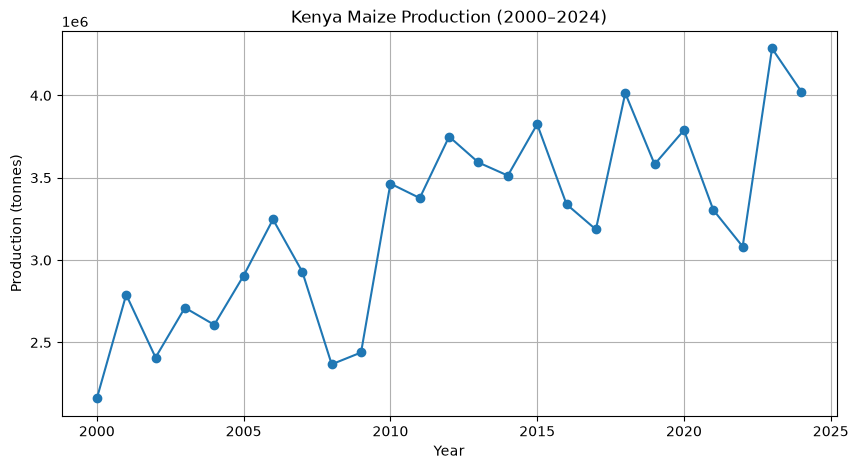

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    combined_data["year"],
    combined_data["production_tonnes"],
    marker="o"
)

plt.title("Kenya Maize Production (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Production (tonnes)")
plt.grid(True)

plt.show()

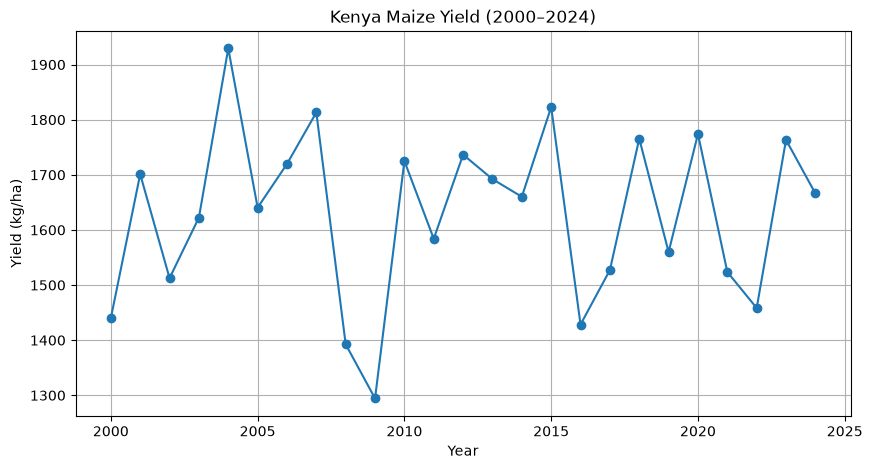

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(
    combined_data["year"],
    combined_data["yield_kg_per_ha"],
    marker="o"
)

plt.title("Kenya Maize Yield (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Yield (kg/ha)")
plt.grid(True)

plt.show()

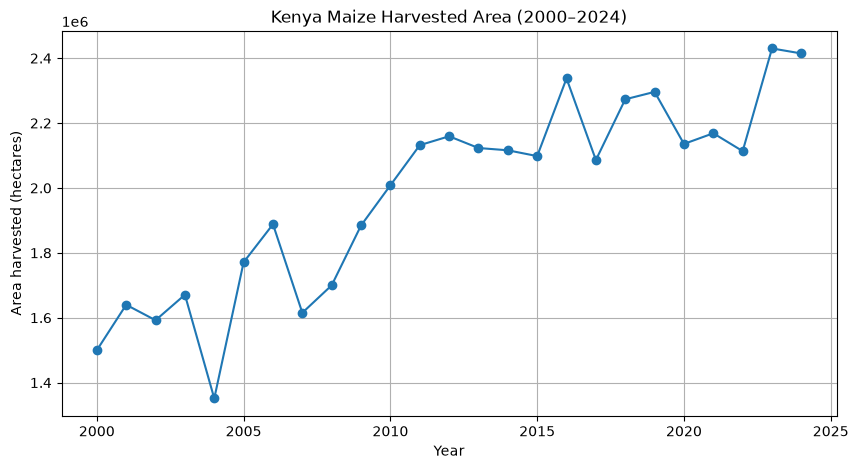

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(
    combined_data["year"],
    combined_data["area_harvested_ha"],
    marker="o"
)

plt.title("Kenya Maize Harvested Area (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Area harvested (hectares)")
plt.grid(True)

plt.show()

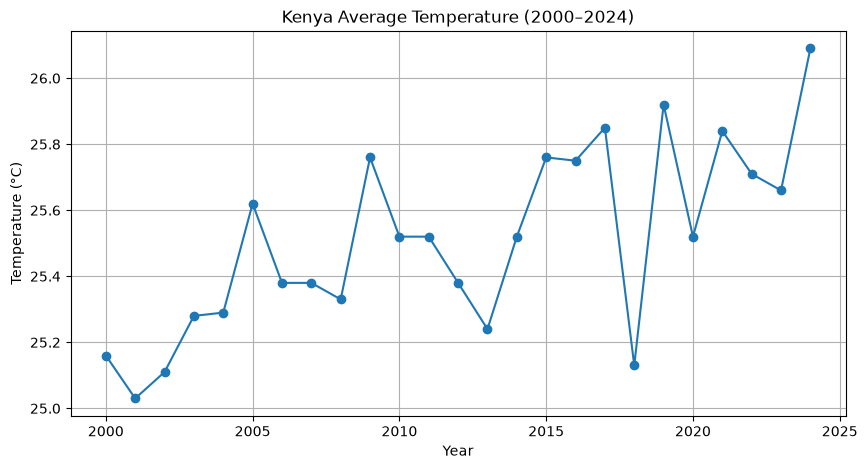

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    combined_data["year"],
    combined_data["temperature"],
    marker="o"
)

plt.title("Kenya Average Temperature (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.show()

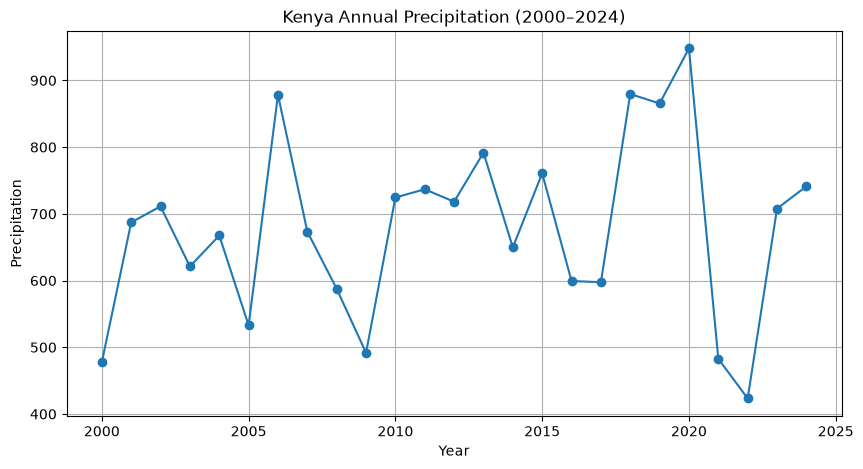

In [38]:
plt.figure(figsize=(10, 5))

plt.plot(
    combined_data["year"],
    combined_data["precipitation"],
    marker="o"
)

plt.title("Kenya Annual Precipitation (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Precipitation")
plt.grid(True)

plt.show()

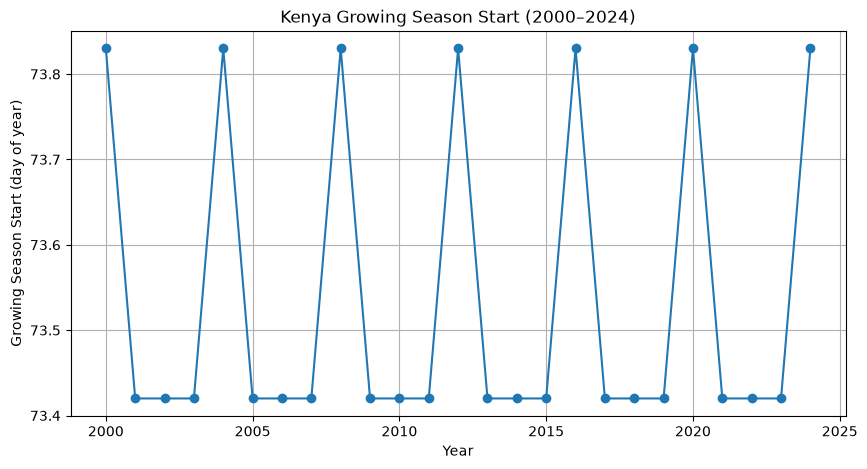

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    combined_data["year"],
    combined_data["growing_season_start"],
    marker="o"
)

plt.title("Kenya Growing Season Start (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Growing Season Start (day of year)")
plt.grid(True)

plt.show()

In [40]:
correlation_variables = [
    "yield_kg_per_ha",
    "production_tonnes",
    "area_harvested_ha",
    "temperature",
    "precipitation",
    "growing_season_start"
]

correlation_matrix = combined_data[correlation_variables].corr()

print("Correlation Matrix:")
print(correlation_matrix.round(2))

Correlation Matrix:
                      yield_kg_per_ha  production_tonnes  area_harvested_ha  \
yield_kg_per_ha                  1.00               0.49              -0.01   
production_tonnes                0.49               1.00               0.86   
area_harvested_ha               -0.01               0.86               1.00   
temperature                     -0.22               0.41               0.63   
precipitation                    0.61               0.58               0.30   
growing_season_start            -0.03              -0.09              -0.08   

                      temperature  precipitation  growing_season_start  
yield_kg_per_ha             -0.22           0.61                 -0.03  
production_tonnes            0.41           0.58                 -0.09  
area_harvested_ha            0.63           0.30                 -0.08  
temperature                  1.00          -0.15                 -0.02  
precipitation               -0.15           1.00             

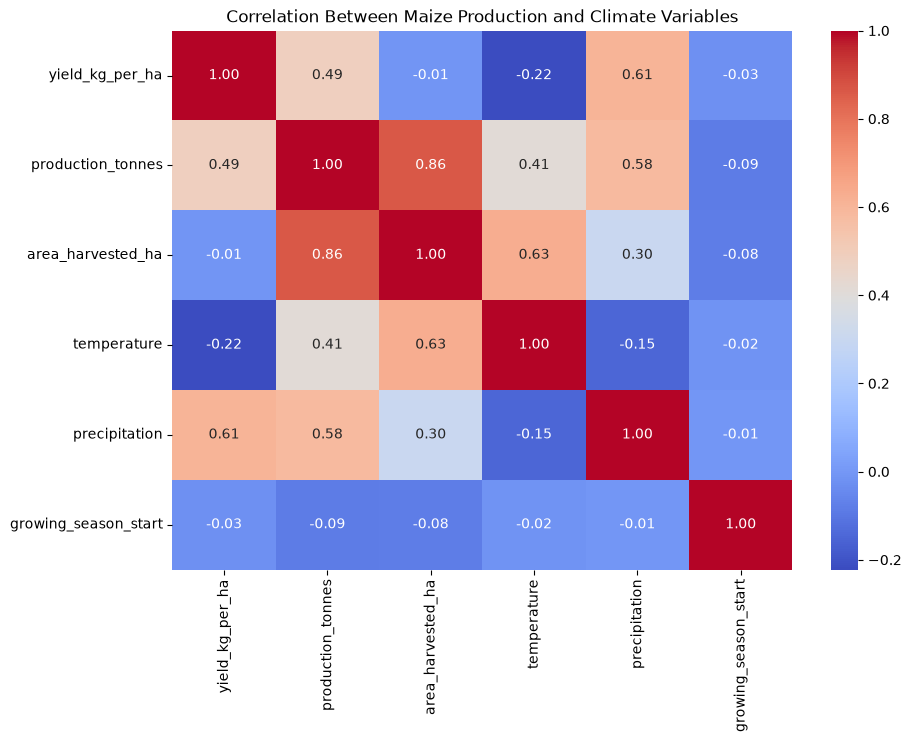

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Maize Production and Climate Variables")
plt.show()

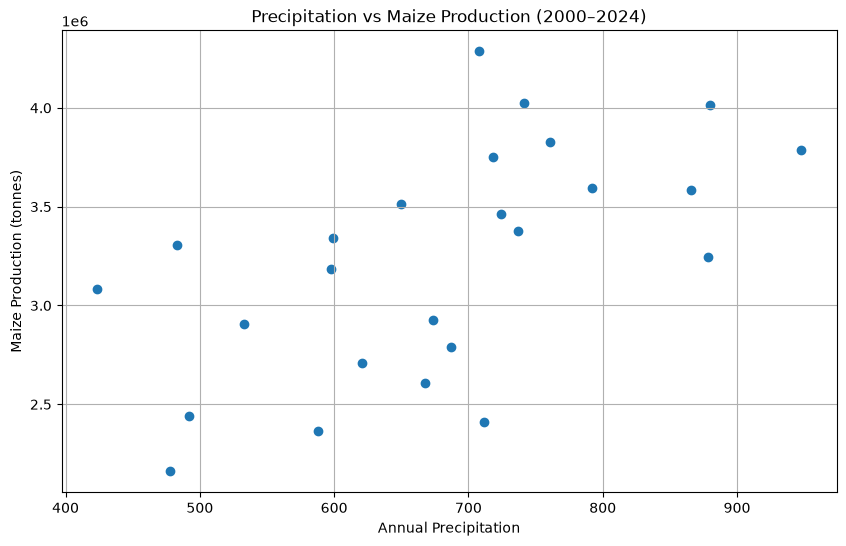

In [42]:
plt.figure(figsize=(10, 6))

plt.scatter(
    combined_data["precipitation"],
    combined_data["production_tonnes"]
)

plt.title("Precipitation vs Maize Production (2000–2024)")
plt.xlabel("Annual Precipitation")
plt.ylabel("Maize Production (tonnes)")

plt.grid(True)

plt.show()

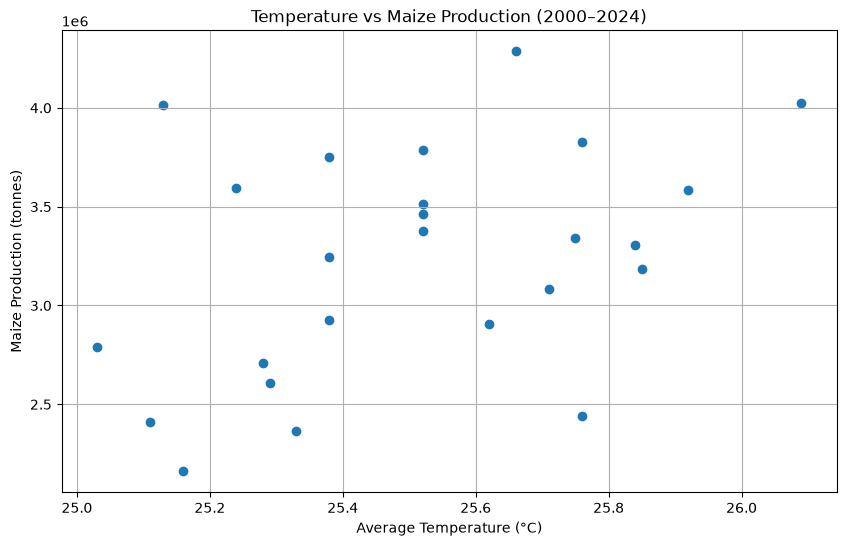

In [43]:
plt.figure(figsize=(10, 6))

plt.scatter(
    combined_data["temperature"],
    combined_data["production_tonnes"]
)

plt.title("Temperature vs Maize Production (2000–2024)")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Maize Production (tonnes)")

plt.grid(True)

plt.show()

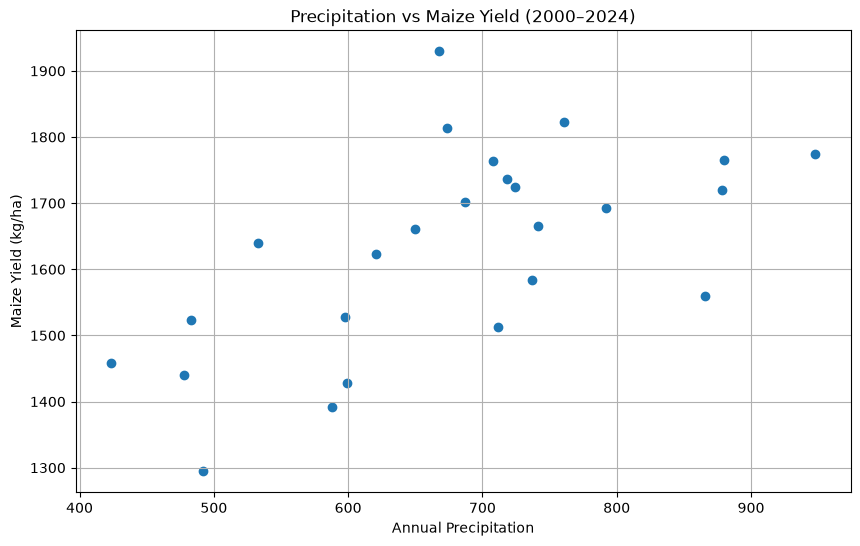

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(
    combined_data["precipitation"],
    combined_data["yield_kg_per_ha"]
)

plt.title("Precipitation vs Maize Yield (2000–2024)")
plt.xlabel("Annual Precipitation")
plt.ylabel("Maize Yield (kg/ha)")

plt.grid(True)

plt.show()

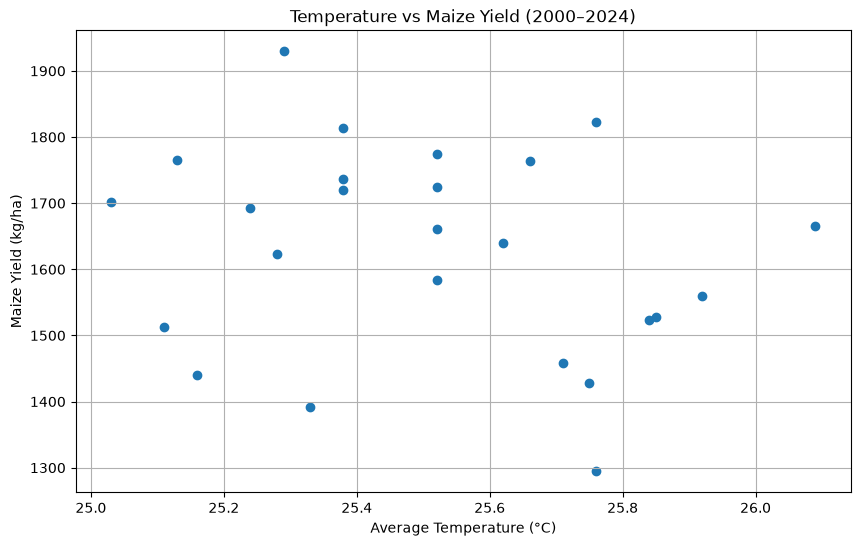

In [45]:
plt.figure(figsize=(10, 6))

plt.scatter(
    combined_data["temperature"],
    combined_data["yield_kg_per_ha"]
)

plt.title("Temperature vs Maize Yield (2000–2024)")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Maize Yield (kg/ha)")

plt.grid(True)

plt.show()

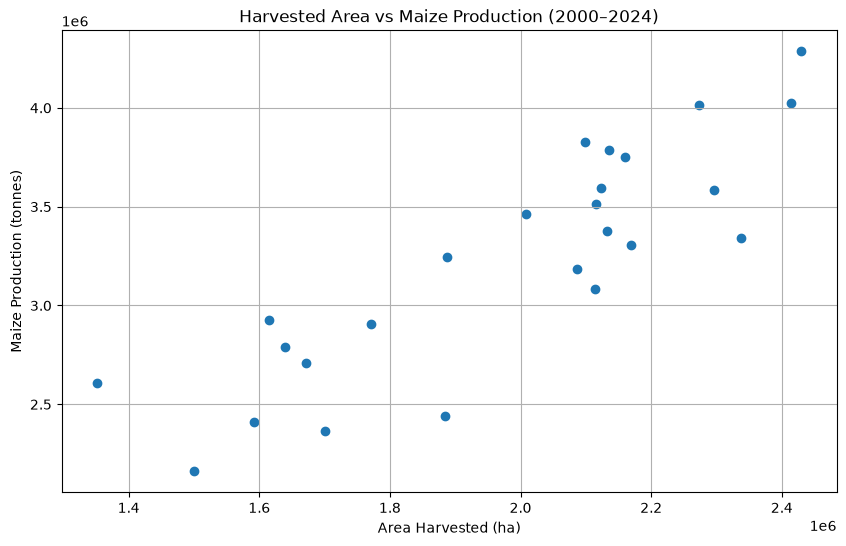

In [46]:
plt.figure(figsize=(10, 6))

plt.scatter(
    combined_data["area_harvested_ha"],
    combined_data["production_tonnes"]
)

plt.title("Harvested Area vs Maize Production (2000–2024)")
plt.xlabel("Area Harvested (ha)")
plt.ylabel("Maize Production (tonnes)")

plt.grid(True)

plt.show()

In [47]:
first_production = combined_data.iloc[0]["production_tonnes"]
last_production = combined_data.iloc[-1]["production_tonnes"]

production_change = last_production - first_production
production_percentage_change = (production_change / first_production) * 100

print(f"Production in 2000: {first_production:,.0f} tonnes")
print(f"Production in 2024: {last_production:,.0f} tonnes")
print(f"Absolute change: {production_change:,.0f} tonnes")
print(f"Percentage change: {production_percentage_change:.2f}%")

Production in 2000: 2,160,000 tonnes
Production in 2024: 4,023,000 tonnes
Absolute change: 1,863,000 tonnes
Percentage change: 86.25%


In [51]:
highest_production = combined_data.loc[
    combined_data["production_tonnes"].idxmax()
]

lowest_production = combined_data.loc[
    combined_data["production_tonnes"].idxmin()
]

print("Highest production year:")
print(highest_production[[
    "year",
    "production_tonnes",
    "yield_kg_per_ha",
    "temperature",
    "precipitation"
]])

print("\nLowest production year:")
print(lowest_production[[
    "year",
    "production_tonnes",
    "yield_kg_per_ha",
    "temperature",
    "precipitation"
]])

Highest production year:
year                      2023
production_tonnes    4285206.0
yield_kg_per_ha         1763.4
temperature              25.66
precipitation           707.85
Name: 23, dtype: object

Lowest production year:
year                      2000
production_tonnes    2160000.0
yield_kg_per_ha         1440.0
temperature              25.16
precipitation           477.52
Name: 0, dtype: object


In [52]:
Q1 = combined_data["production_tonnes"].quantile(0.25)

In [53]:
Q3 = combined_data["production_tonnes"].quantile(0.75)

In [54]:
IQR = Q3 - Q1

In [55]:
lower_bound = Q1 - (1.5 * IQR)

In [56]:
upper_bound = Q3 + (1.5 * IQR)

In [57]:
outliers = combined_data[
    (combined_data["production_tonnes"] < lower_bound) |
    (combined_data["production_tonnes"] > upper_bound)
]

print("Production outliers:")
print(outliers[[
    "year",
    "production_tonnes",
    "yield_kg_per_ha",
    "temperature",
    "precipitation"
]])

Production outliers:
Empty DataFrame
Columns: [year, production_tonnes, yield_kg_per_ha, temperature, precipitation]
Index: []


In [58]:
Q1_yield = combined_data["yield_kg_per_ha"].quantile(0.25)

print("Q1 for yield:", Q1_yield)

Q1 for yield: 1523.8


In [59]:
Q3_yield = combined_data["yield_kg_per_ha"].quantile(0.75)

print("Q3 for yield:", Q3_yield)

Q3 for yield: 1736.6


In [60]:
# Calculate the first quartile (Q1)
Q1_yield = combined_data["yield_kg_per_ha"].quantile(0.25)

# Calculate the third quartile (Q3)
Q3_yield = combined_data["yield_kg_per_ha"].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR_yield = Q3_yield - Q1_yield

# Calculate the lower boundary for detecting outliers
lower_bound_yield = Q1_yield - (1.5 * IQR_yield)

# Calculate the upper boundary for detecting outliers
upper_bound_yield = Q3_yield + (1.5 * IQR_yield)

# Identify yield values outside the boundaries
yield_outliers = combined_data[
    (combined_data["yield_kg_per_ha"] < lower_bound_yield) |
    (combined_data["yield_kg_per_ha"] > upper_bound_yield)
]

# Display the results
print("Q1 for yield:", Q1_yield)
print("Q3 for yield:", Q3_yield)
print("IQR for yield:", IQR_yield)
print("Lower boundary:", lower_bound_yield)
print("Upper boundary:", upper_bound_yield)

print("\nYield outliers:")
print(yield_outliers[[
    "year",
    "yield_kg_per_ha",
    "production_tonnes",
    "temperature",
    "precipitation"
]])

Q1 for yield: 1523.8
Q3 for yield: 1736.6
IQR for yield: 212.79999999999995
Lower boundary: 1204.6
Upper boundary: 2055.7999999999997

Yield outliers:
Empty DataFrame
Columns: [year, yield_kg_per_ha, production_tonnes, temperature, precipitation]
Index: []


In [61]:
# Calculate Q1 for temperature
Q1_temperature = combined_data["temperature"].quantile(0.25)

# Calculate Q3 for temperature
Q3_temperature = combined_data["temperature"].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR_temperature = Q3_temperature - Q1_temperature

# Calculate the lower boundary
lower_bound_temperature = Q1_temperature - (1.5 * IQR_temperature)

# Calculate the upper boundary
upper_bound_temperature = Q3_temperature + (1.5 * IQR_temperature)

# Identify temperature outliers
temperature_outliers = combined_data[
    (combined_data["temperature"] < lower_bound_temperature) |
    (combined_data["temperature"] > upper_bound_temperature)
]

# Display the results
print("Q1 for temperature:", Q1_temperature)
print("Q3 for temperature:", Q3_temperature)
print("IQR for temperature:", IQR_temperature)
print("Lower boundary:", lower_bound_temperature)
print("Upper boundary:", upper_bound_temperature)

print("\nTemperature outliers:")
print(temperature_outliers[[
    "year",
    "temperature",
    "production_tonnes",
    "yield_kg_per_ha",
    "precipitation"
]])

Q1 for temperature: 25.29
Q3 for temperature: 25.75
IQR for temperature: 0.46000000000000085
Lower boundary: 24.599999999999998
Upper boundary: 26.44

Temperature outliers:
Empty DataFrame
Columns: [year, temperature, production_tonnes, yield_kg_per_ha, precipitation]
Index: []


In [62]:
Q1_precipitation = combined_data["precipitation"].quantile(0.25)

Q3_precipitation = combined_data["precipitation"].quantile(0.75)

IQR_precipitation = Q3_precipitation - Q1_precipitation

lower_bound_precipitation = Q1_precipitation - (1.5 * IQR_precipitation)

upper_bound_precipitation = Q3_precipitation + (1.5 * IQR_precipitation)

precipitation_outliers = combined_data[
    (combined_data["precipitation"] < lower_bound_precipitation) |
    (combined_data["precipitation"] > upper_bound_precipitation)
]

print("Q1 for precipitation:", Q1_precipitation)
print("Q3 for precipitation:", Q3_precipitation)
print("IQR for precipitation:", IQR_precipitation)
print("Lower boundary:", lower_bound_precipitation)
print("Upper boundary:", upper_bound_precipitation)

print("\nPrecipitation outliers:")
print(precipitation_outliers[[
    "year",
    "precipitation",
    "production_tonnes",
    "yield_kg_per_ha",
    "temperature"
]])

Q1 for precipitation: 597.52
Q3 for precipitation: 741.3
IQR for precipitation: 143.77999999999997
Lower boundary: 381.85
Upper boundary: 956.9699999999999

Precipitation outliers:
Empty DataFrame
Columns: [year, precipitation, production_tonnes, yield_kg_per_ha, temperature]
Index: []


In [63]:
yield_climate_correlation = combined_data[
    [
        "yield_kg_per_ha",
        "temperature",
        "precipitation",
        "growing_season_start"
    ]
].corr()

print(yield_climate_correlation.round(2))

                      yield_kg_per_ha  temperature  precipitation  \
yield_kg_per_ha                  1.00        -0.22           0.61   
temperature                     -0.22         1.00          -0.15   
precipitation                    0.61        -0.15           1.00   
growing_season_start            -0.03        -0.02          -0.01   

                      growing_season_start  
yield_kg_per_ha                      -0.03  
temperature                          -0.02  
precipitation                        -0.01  
growing_season_start                  1.00  


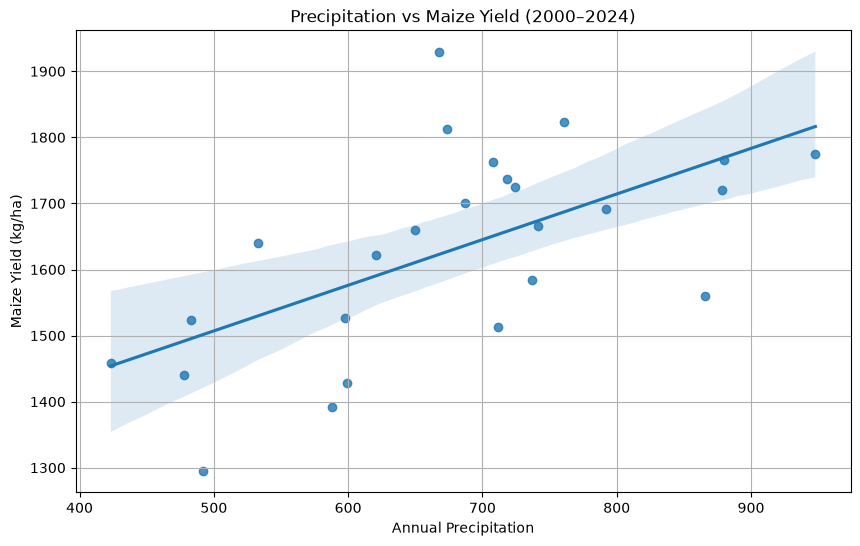

In [64]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=combined_data,
    x="precipitation",
    y="yield_kg_per_ha"
)

plt.title("Precipitation vs Maize Yield (2000–2024)")
plt.xlabel("Annual Precipitation")
plt.ylabel("Maize Yield (kg/ha)")
plt.grid(True)

plt.show()

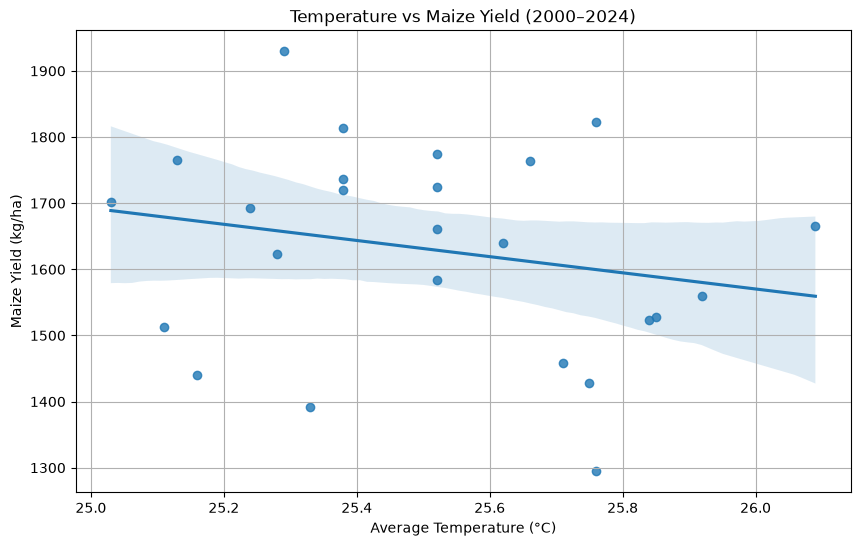

In [65]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=combined_data,
    x="temperature",
    y="yield_kg_per_ha"
)

plt.title("Temperature vs Maize Yield (2000–2024)")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Maize Yield (kg/ha)")
plt.grid(True)

plt.show()

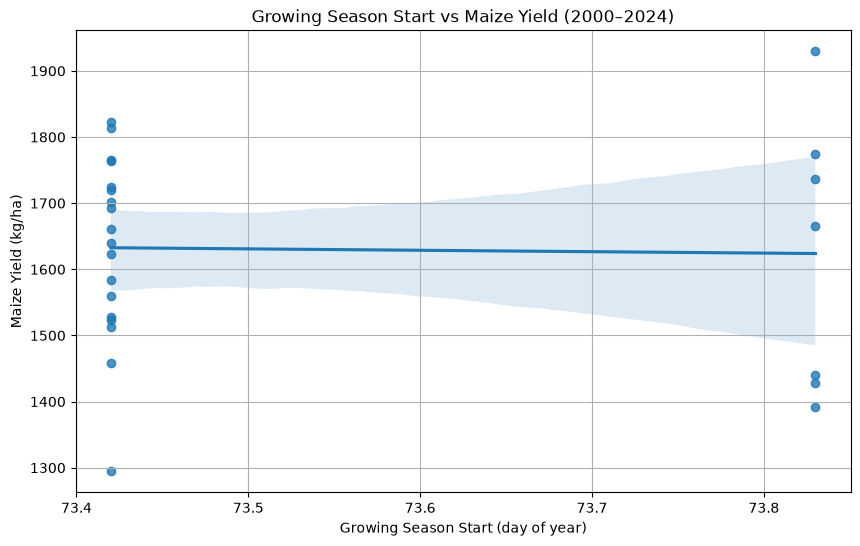

In [66]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=combined_data,
    x="growing_season_start",
    y="yield_kg_per_ha"
)

plt.title("Growing Season Start vs Maize Yield (2000–2024)")
plt.xlabel("Growing Season Start (day of year)")
plt.ylabel("Maize Yield (kg/ha)")
plt.grid(True)

plt.show()

In [67]:
first_year = combined_data.iloc[0]
last_year = combined_data.iloc[-1]

print("2000 values:")
print(first_year[[
    "year",
    "production_tonnes",
    "yield_kg_per_ha",
    "area_harvested_ha"
]])

print("\n2024 values:")
print(last_year[[
    "year",
    "production_tonnes",
    "yield_kg_per_ha",
    "area_harvested_ha"
]])

2000 values:
year                      2000
production_tonnes    2160000.0
yield_kg_per_ha         1440.0
area_harvested_ha    1500000.0
Name: 0, dtype: object

2024 values:
year                      2024
production_tonnes    4023000.0
yield_kg_per_ha         1666.2
area_harvested_ha    2414536.0
Name: 24, dtype: object


In [68]:
production_change = ((last_year["production_tonnes"] - first_year["production_tonnes"]) / first_year["production_tonnes"]) * 100

yield_change = ((last_year["yield_kg_per_ha"] - first_year["yield_kg_per_ha"]) / first_year["yield_kg_per_ha"]) * 100

area_change = ((last_year["area_harvested_ha"] - first_year["area_harvested_ha"]) / first_year["area_harvested_ha"]) * 100

print(f"Production percentage change: {production_change:.2f}%")
print(f"Yield percentage change: {yield_change:.2f}%")
print(f"Harvested area percentage change: {area_change:.2f}%")

Production percentage change: 86.25%
Yield percentage change: 15.71%
Harvested area percentage change: 60.97%


In [79]:
old_production = first_year["production_tonnes"]
old_yield = first_year["yield_kg_per_ha"]
new_yield = last_year["yield_kg_per_ha"]
old_area = first_year["area_harvested_ha"]
new_area = last_year["area_harvested_ha"]

area_effect = (new_area - old_area) * old_yield / 1000

yield_effect = (new_yield - old_yield) * old_area / 1000

interaction_effect = (new_area - old_area) * (new_yield - old_yield) / 1000

total_change = new_area * new_yield / 1000 - old_production

print(f"Area effect: {area_effect:,.0f} tonnes")
print(f"Yield effect: {yield_effect:,.0f} tonnes")
print(f"Interaction effect: {interaction_effect:,.0f} tonnes")
print(f"Total production change: {total_change:,.0f} tonnes")

Area effect: 1,316,932 tonnes
Yield effect: 339,300 tonnes
Interaction effect: 206,868 tonnes
Total production change: 1,863,100 tonnes


In [80]:
area_effect_percentage = (area_effect / total_change) * 100

yield_effect_percentage = (yield_effect / total_change) * 100

interaction_effect_percentage = (interaction_effect / total_change) * 100

print(f"Area effect percentage: {area_effect_percentage:.2f}%")
print(f"Yield effect percentage: {yield_effect_percentage:.2f}%")
print(f"Interaction effect percentage: {interaction_effect_percentage:.2f}%")

Area effect percentage: 70.68%
Yield effect percentage: 18.21%
Interaction effect percentage: 11.10%
